# Proyecto Integrador - Equipo 16
## Avance 4: Modelos de Árboles con Predicción Periódica (Independiente)
**Integrantes:**
- Luis Mauricio Castro Gutiérrez - A01795088
- Gerardo Miguel Pérez Solis - A01795599
- Amiel Joel Rosete Islas - A01748598

---

En este notebook experimentaremos con modelos independientes por cada período (1 mes, 2 meses y 3 meses a futuro) utilizando algoritmos de regresión basados en árboles: **XGBoost, LightGBM y Random Forest**. 

Adicionalmente, se incluyen nuevas **variables exógenas**:
1. **Isolation Forest Score**: Indicador multivariante de anomalías.
2. **Bayesian Hierarchical Score**: Probabilidad anómala obtenida vía distribución predictiva Poisson-Gamma.
3. **Vacunas con desfase**: Datos totales de vacunación con desfase dinámico para medir su impacto retardado, recortando las muestras sin datos.

Se desarrollarán modelos independientes para cada horizonte de predicción (`h=1`, `h=2`, `h=3` meses) y se evaluarán utilizando las métricas MAE, RMSE y SMAPE.

los modelos evaluados son:



| Modelo         | Descripción breve                                                                 |
|----------------|----------------------------------------------------------------------------------|
| **XGBoost**    | Algoritmo de boosting basado en árboles, eficiente y robusto para regresión.      |
| **LightGBM**   | Variante de boosting que optimiza velocidad y memoria, ideal para grandes datos.  |
| **Random Forest** | Ensamble de múltiples árboles de decisión entrenados con bagging, robusto ante sobreajuste. |


In [39]:
# Importación de Librerias
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.stats import nbinom as nbinom_dist
from sklearn.ensemble import IsolationForest, RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuraciones para evitar warnings y mostrar todas las columnas
pd.set_option("display.max_columns", None)
np.seterr(divide="ignore", invalid="ignore")
warnings.filterwarnings("ignore")



## 1. Carga de Datos y Variables Exógenas

Aquí cargaremos el dataset principal (`df_fe`) y el de vacunas. Evaluaremos los Scores de Anómalia que sirvieron de detector en el entregable de baseline para incluirlos como características al modelo predictivo.

In [40]:
# Accesso a la carpeta de datos procesados para la carga de datasets
base_path = Path("../../../..") / "data" / "processed"

# Dataset de Features (Ingeniería de caracteristicas previa)
df_fe = pd.read_csv(base_path / "dataset_sarampion_features_engineered.csv")
df_fe["fecha"] = pd.to_datetime(df_fe["fecha"])
df_fe = df_fe.sort_values("fecha").reset_index(drop=True)

# Dataset original con los totales de dosis (Vacunas)
df_vacunas = pd.read_csv(base_path / "dataset_sarampion_vacunas_2010-2023.csv")
df_vacunas["fecha"] = pd.to_datetime(
    df_vacunas["anio"].astype(str) + "-" + df_vacunas["mes"].astype(str) + "-01"
)
df_vacunas = df_vacunas.sort_values("fecha").reset_index(drop=True)

df_fe["brote"] = (df_fe["casos_sarampion"] > 0).astype(int)
df_vacunas["brote"] = (df_vacunas["casos_sarampion"] > 0).astype(int)

# 1. Feature de Isolation Forest
# Excluir columnas temporales y componentes estáticos como PCA/Factor que no capturan dinámica temporal
exclude_cols = {"fecha", "anio", "mes", "casos_sarampion", "brote"} | {c for c in df_fe.columns if 'pca' in c.lower() or 'factor' in c.lower()}
# mostrar qué columnas PCA/Factor se están excluyendo (diagnóstico)
print('Excluyendo PCA/Factor del entrenamiento de IsolationForest:', sorted([c for c in df_fe.columns if 'pca' in c.lower() or 'factor' in c.lower()]))
feature_cols = [c for c in df_fe.columns if c not in exclude_cols]

# Ajustaremos la anomalía usando entrenamiento (< 2019) como base para no filtrar información del futuro
train_mask = df_fe["anio"] < 2019
X_train_if = df_fe.loc[train_mask, feature_cols].values
cont_rate = max(df_fe.loc[train_mask, "brote"].mean(), 0.01)

# Aplicamos Isolation Forest para detectar anomalías en el conjunto de entrenamiento y luego aplicamos el modelo a todo el dataset para obtener un score de anomalía que se agregará como nueva característica.
iso_forest = IsolationForest(n_estimators=200, contamination=cont_rate, random_state=42, n_jobs=-1)
iso_forest.fit(X_train_if)

# Mayor score (al multiplicar por negativo) = Más anómalo
df_fe["isolation_forest_score"] = -iso_forest.decision_function(df_fe[feature_cols].values)

# 2. Feature Bayesiana (Poisson-Gamma)
def calcular_bayesian_score(df, split_year=2019):
    train_mask = df["anio"] < split_year
    train_raw = df[train_mask]
    
    global_mean_train = train_raw["casos_sarampion"].mean()
    global_var_train  = train_raw["casos_sarampion"].var()

    if global_var_train > global_mean_train and global_mean_train > 0:
        beta_0  = global_mean_train / max(global_var_train, 1e-6)
        alpha_0 = global_mean_train * beta_0
    else:
        alpha_0, beta_0 = 0.5, 0.5
        
    posteriors_by_month = {}
    for mes in range(1, 13):
        month_data = train_raw[train_raw["mes"] == mes]["casos_sarampion"]
        n_m    = len(month_data)
        sum_ym = int(month_data.sum())
        alpha_post = alpha_0 + sum_ym
        beta_post  = beta_0 + n_m
        posteriors_by_month[mes] = (alpha_post, beta_post)

    bayes_pvalues = np.zeros(len(df))
    for idx in range(len(df)):
        mes   = int(df.iloc[idx]["mes"])
        y_obs = int(df.iloc[idx]["casos_sarampion"])
        alpha_post, beta_post = posteriors_by_month[mes]
        
        r = alpha_post
        p = beta_post / (1.0 + beta_post)
        if y_obs > 0:
            p_value = 1.0 - nbinom_dist.cdf(y_obs - 1, r, p)
        else:
            p_value = 1.0
        bayes_pvalues[idx] = p_value
        
    return 1.0 - bayes_pvalues

df_fe["bayesian_score"] = calcular_bayesian_score(df_vacunas)

print("Exógenas Isolation Forest y Bayesian agregadas a df_fe.")


Excluyendo PCA/Factor del entrenamiento de IsolationForest: ['PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'PCA_6', 'PCA_7']
Exógenas Isolation Forest y Bayesian agregadas a df_fe.


## 2. Inserción de Vacunas con Desfase (Variable Editable)
Se integra una variable de desfase en meses, ya que no tenemos claro si usar los desfases explorados en el baseline o algun desfase diferente.

In [41]:
MESES_DESFASE = 2  # <--- Editable a 4,11,15 meses dependiendo lo comentado con las doctoras.

def integrar_vacunas_con_desfase(df_principal, df_vac, desfase_meses=0):
    df_vac_lag = df_vac.copy()
    
    # Desplazamos las fechas sumándole los meses de desfase para empatar la dosis del pasado al mes actual
    df_vac_lag["fecha_join"] = df_vac_lag["fecha"] + pd.DateOffset(months=desfase_meses)
    
    col_name = f"total_dosis_lag_{desfase_meses}m"
    df_vac_lag = df_vac_lag[["fecha_join", "total_dosis"]].rename(
        columns={"total_dosis": col_name}
    )
    
    df_res = pd.merge(df_principal, df_vac_lag, left_on="fecha", right_on="fecha_join", how="left")
    df_res.drop(columns=["fecha_join"], inplace=True)
    
    # Borrar los meses que no tengan datos de vacunas debido al desfase (ya que no se podrían usar para modelar)
    df_res.dropna(subset=[col_name], inplace=True)
    
    return df_res.reset_index(drop=True)

df_model = integrar_vacunas_con_desfase(df_fe, df_vacunas, desfase_meses=MESES_DESFASE)
print("Forma del dataset de modelación luego de dropear NaNs por desfase:", df_model.shape)


Forma del dataset de modelación luego de dropear NaNs por desfase: (166, 30)


## 3. Train-Test Split por Periodos Editable
Separamos estrictamente la información cronológica antes de la construcción de objetivos (targets).
Por ser un problema de **Series de Tiempo**, debemos utilizar la información pasada para predecir a 1, 2 o 3 meses. El split previene el *data leakage* (fuga de datos futuros al pasado).

In [42]:
# Editable period limits (Entrenamiento vs Prueba)
# Esta modificable para poder definirlo segun lo establezcamos.
TRAIN_START_YEAR = 2010
TRAIN_END_YEAR = 2018 # <=2018 is train
TEST_START_YEAR = 2019
TEST_END_YEAR = 2023 # >=2019 is test

# Filtramos el dataset para quedarnos solo con los años que vamos a usar en entrenamiento y prueba, eliminando años anteriores a 2010 o posteriores a 2023.
df_model = df_model[(df_model["anio"] >= TRAIN_START_YEAR) & (df_model["anio"] <= TEST_END_YEAR)].copy()

# Features a excluir en los predictores (excluimos PCA/Factor estáticos) 
cols_to_exclude = {"fecha", "anio", "mes", "casos_sarampion", "brote"} | {c for c in df_model.columns if 'pca' in c.lower() or 'factor' in c.lower()}
model_features = [c for c in df_model.columns if c not in cols_to_exclude]
print('Se excluyen de model_features las columnas:', sorted([c for c in df_model.columns if 'pca' in c.lower() or 'factor' in c.lower()]))

print(f"Número de predictores finales: {len(model_features)}")


Se excluyen de model_features las columnas: ['PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'PCA_6', 'PCA_7']
Número de predictores finales: 18


**Nota (razón de exclusión de PCA/Factor):**
- Las columnas `PCA_*` y cualquier `factor` son resúmenes estáticos lineales de la información cómputo-multivariada. No preservan explícitamente la dinámica temporal (lags, tendencias o estacionalidad) ni el desfase causal entre regresoras y objetivo.
- Para forecasting de series de tiempo preferimos features directamente interpretables en el tiempo: `lags`, estadísticas rolling (media, std), indicadores estacionales y variables exógenas con desfase. Estas capturan la dinámica temporal que los modelos usan para predecir correctamente en horizontes futuros.
- Por eso excluimos PCA/Factor de los predictores: reducen riesgo de borrar señales temporales útiles y empeorar la interpretabilidad del modelo.

## 4. Time-Series Forecasting: Direct Multi-step por Horizontes
Crearemos un ciclo para construir y evaluar modelos XGBoost, LightGBM y Random Forest independientemente para predecir a `h` meses (1, 2 y 3 meses).

En el modelado *Direct Forecasting*, para un horizonte `h`, desplazamos nuestro objetivo `h` pasos hacia atrás: predecimos `casos_sarampion_{t+h}` usando la información de las regresoras en el instante `t`.

Es importante saber diferenciar entre direct y recursive forecasting, por lo que se muestra un diagrama explicativo de ambos enfoques:
![Direct vs Recursive Forecasting](https://media.licdn.com/dms/image/v2/D4E22AQEAKwqToZkFTA/feedshare-shrink_800/feedshare-shrink_800/0/1700679304644?e=2147483647&v=beta&t=In7RtNkBQXEgYdLn1mX6ByvWBeP8QZFC3Fynd3B86Cw)

**Proceso que se tomara por cada horizonte en el codigo**

Para cada horizonte `h` se realiza:

1. Crear un dataset `df_h` específico y desplazar el objetivo `casos_sarampion` h meses hacia atrás → `target_h{h}`
2. Eliminar filas sin objetivo (últimos h meses)
3. Particionar cronológicamente en train/test usando `TRAIN_END_YEAR` y `TEST_START_YEAR` para evitar data leakage
4. Entrenar modelos (XGBoost, LightGBM, Random Forest) con `model_features` como predictores
5. Predecir sobre `X_test`, recortar predicciones negativas a 0 y calcular métricas: MAE, RMSE y SMAPE
6. Guardar resultados en `resultados_globales` para visualización y comparativas finales

In [43]:
# --- Grid search temporal para hiperparámetros ---
from sklearn.model_selection import TimeSeriesSplit
import math

param_grids = {
    "XGBoost": [
        {"n_estimators": 100, "max_depth": 3, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8, "reg_alpha": 0.1, "reg_lambda": 1.0},
        {"n_estimators": 200, "max_depth": 4, "learning_rate": 0.03, "subsample": 0.8, "colsample_bytree": 0.8, "reg_alpha": 0.5, "reg_lambda": 1.5},
        {"n_estimators": 150, "max_depth": 5, "learning_rate": 0.05, "subsample": 0.9, "colsample_bytree": 0.7, "reg_alpha": 0.0, "reg_lambda": 1.0},
        {"n_estimators": 300, "max_depth": 3, "learning_rate": 0.01, "subsample": 0.7, "colsample_bytree": 0.9, "reg_alpha": 1.0, "reg_lambda": 2.0},
        {"n_estimators": 200, "max_depth": 6, "learning_rate": 0.05, "subsample": 0.85, "colsample_bytree": 0.8, "reg_alpha": 0.1, "reg_lambda": 0.5},
    ],
    "LightGBM": [
        {"n_estimators": 100, "max_depth": 3, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8, "reg_alpha": 0.1, "reg_lambda": 1.0, "num_leaves": 15},
        {"n_estimators": 200, "max_depth": 4, "learning_rate": 0.03, "subsample": 0.8, "colsample_bytree": 0.8, "reg_alpha": 0.5, "reg_lambda": 1.5, "num_leaves": 20},
        {"n_estimators": 150, "max_depth": 5, "learning_rate": 0.05, "subsample": 0.9, "colsample_bytree": 0.7, "reg_alpha": 0.0, "reg_lambda": 1.0, "num_leaves": 31},
        {"n_estimators": 300, "max_depth": -1, "learning_rate": 0.01, "subsample": 0.7, "colsample_bytree": 0.9, "reg_alpha": 1.0, "reg_lambda": 2.0, "num_leaves": 15},
        {"n_estimators": 200, "max_depth": 6, "learning_rate": 0.05, "subsample": 0.85, "colsample_bytree": 0.8, "reg_alpha": 0.1, "reg_lambda": 0.5, "num_leaves": 25},
    ],
    "RandomForest": [
        {"n_estimators": 100, "max_depth": 5, "min_samples_split": 5, "min_samples_leaf": 2, "max_features": "sqrt"},
        {"n_estimators": 200, "max_depth": 7, "min_samples_split": 3, "min_samples_leaf": 2, "max_features": 0.7},
        {"n_estimators": 300, "max_depth": 10, "min_samples_split": 2, "min_samples_leaf": 1, "max_features": "sqrt"},
        {"n_estimators": 200, "max_depth": None, "min_samples_split": 5, "min_samples_leaf": 3, "max_features": 0.5},
        {"n_estimators": 150, "max_depth": 8, "min_samples_split": 4, "min_samples_leaf": 2, "max_features": "log2"},
    ],
}

def tune_models(train_df, feature_cols, n_splits=3):
    """Realiza un grid-search temporal usando TimeSeriesSplit sobre `train_df`."""
    X = train_df[feature_cols].values
    y = train_df['casos_sarampion'].values
    tsc = TimeSeriesSplit(n_splits=n_splits)
    best_models = {}

    for name, grid in param_grids.items():
        best_score = math.inf
        best_params = None
        for params in grid:
            # convert None/NaN JSON null to Python None if present
            params_clean = {k: (None if v is None else v) for k, v in params.items()}
            rmses = []
            for train_idx, val_idx in tsc.split(X):
                X_tr, X_val = X[train_idx], X[val_idx]
                y_tr, y_val = y[train_idx], y[val_idx]
                if name == 'XGBoost':
                    m = xgb.XGBRegressor(**params_clean, random_state=42, n_jobs=-1)
                elif name == 'LightGBM':
                    m = lgb.LGBMRegressor(**params_clean, random_state=42, verbose=-1)
                else:
                    m = RandomForestRegressor(**params_clean, random_state=42, n_jobs=-1)
                m.fit(X_tr, y_tr)
                preds = m.predict(X_val)
                rmses.append(np.sqrt(mean_squared_error(y_val, preds)))
            mean_rmse = np.mean(rmses)
            if mean_rmse < best_score:
                best_score = mean_rmse
                best_params = params_clean
        # Entrenar modelo final con los mejores parámetros sobre todo train_df
        if name == 'XGBoost':
            final = xgb.XGBRegressor(**best_params, random_state=42, n_jobs=-1)
        elif name == 'LightGBM':
            final = lgb.LGBMRegressor(**best_params, random_state=42, verbose=-1)
        else:
            final = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
        final.fit(X, y)
        best_models[name] = final
        print(f'Best {name}: params={best_params} cv_rmse={best_score:.4f}')
    return best_models

# Uso: llamar `tune_models(train_df, model_features)` dentro del flujo temporal antes de entrenar sobre test.

In [44]:
# función para calcular SMAPE (Symmetric Mean Absolute Percentage Error)
def smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred))
    # Avoid division by zero
    denominator = np.where(denominator == 0, 1, denominator)
    return 100 * np.mean(np.abs(y_pred - y_true) / denominator)

# Lista de horizontes de predicción en meses
horizontes = [1, 2, 3]

# Usaremos únicamente los modelos retornados por `tune_models(train_df, model_features)`
# (Los modelos por defecto fueron eliminados para evitar ambigüedad y asegurar que solo se usen los modelos afinados)

resultados_globales = []

for h in horizontes:
    print(f"\n{'='*50}")
    print(f" MODELANDO HORIZONTE: {h} MESES AL FUTURO (t+{h})")
    print(f"{'='*50}")
    
    # Creamos un dataset específico para este horizonte
    df_h = df_model.copy()
    
    # Objetivo desplazado: el objetivo es el caso_sarampion del tiempo que ocurrirá h meses después.
    target_col = f"target_h{h}"
    df_h[target_col] = df_h["casos_sarampion"].shift(-h)
    
    # Borramos los últimos h meses, ya que no tendremos horizonte de evaluación final en la historia (NaNs)
    df_h.dropna(subset=[target_col], inplace=True)
    
    # Partición temporal
    train_mask = df_h["anio"] <= TRAIN_END_YEAR
    test_mask = df_h["anio"] >= TEST_START_YEAR
    
    train_df = df_h[train_mask]
    test_df = df_h[test_mask]
    
    # Afinar modelos por grid-search temporal usando solo los datos de entrenamiento
    tuned_modelos = tune_models(train_df, model_features)
    iter_models = tuned_modelos
    
    X_train = train_df[model_features].values
    y_train = train_df[target_col].values
    
    X_test = test_df[model_features].values
    y_test = test_df[target_col].values
    
    for nombre_modelo, modelo in iter_models.items():
        # Entrenamiento del modelo (ya afinado)
        # Los modelos retornados por tune_models ya están entrenados sobre train_df
        preds = modelo.predict(X_test)
        preds = np.maximum(preds, 0) # Clip a cero si el modelo regresa valores negativos en un número real de casos
        
        # Metrics: MAE, RMSE y SMAPE
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        smape_val = smape(y_test, preds)
        
        # Imprimimos métricas resumidas por modelo y horizonte
        print(f"[{nombre_modelo}] Horizonte {h}m -> MAE: {mae:.4f} | RMSE: {rmse:.4f} | SMAPE: {smape_val:.2f}%")
        
        # Guardamos resultados para el resumen y las gráficas finales
        resultados_globales.append({
            "Horizonte (Meses)": h,
            "Modelo": nombre_modelo,
            "MAE": mae,
            "RMSE": rmse,
            "SMAPE": smape_val
        })
        


 MODELANDO HORIZONTE: 1 MESES AL FUTURO (t+1)
Best XGBoost: params={'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.5, 'reg_lambda': 1.5} cv_rmse=0.9718
Best LightGBM: params={'n_estimators': 300, 'max_depth': -1, 'learning_rate': 0.01, 'subsample': 0.7, 'colsample_bytree': 0.9, 'reg_alpha': 1.0, 'reg_lambda': 2.0, 'num_leaves': 15} cv_rmse=5.6808
Best RandomForest: params={'n_estimators': 200, 'max_depth': 7, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 0.7} cv_rmse=1.2486
[XGBoost] Horizonte 1m -> MAE: 3.8754 | RMSE: 13.5107 | SMAPE: 93.18%
[LightGBM] Horizonte 1m -> MAE: 4.8098 | RMSE: 13.1400 | SMAPE: 70.36%
[RandomForest] Horizonte 1m -> MAE: 3.9579 | RMSE: 12.2626 | SMAPE: 58.59%

 MODELANDO HORIZONTE: 2 MESES AL FUTURO (t+2)
Best XGBoost: params={'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.5, 'reg_lambda': 1.5} cv_rmse

## 5. Resumen de Modelos a Distintos Horizontes y Comparativa Final

,Horizonte (Meses),Modelo,MAE,RMSE,SMAPE
2,1,RandomForest,3.957899,12.262623,58.588744
1,1,LightGBM,4.809752,13.139983,70.364265
0,1,XGBoost,3.875372,13.510748,93.175026
4,2,LightGBM,5.203166,13.910228,73.051855
3,2,XGBoost,5.063636,15.710185,95.103205
5,2,RandomForest,5.392566,15.807185,61.623165
7,3,LightGBM,5.699088,14.360073,77.802561
6,3,XGBoost,5.872232,16.616337,96.295188
8,3,RandomForest,6.769387,17.232432,65.245230


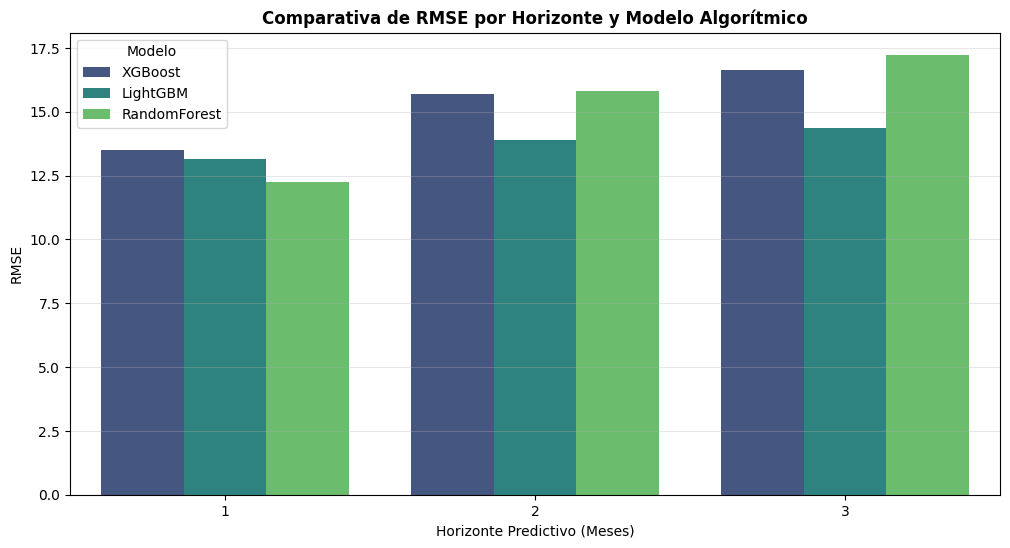

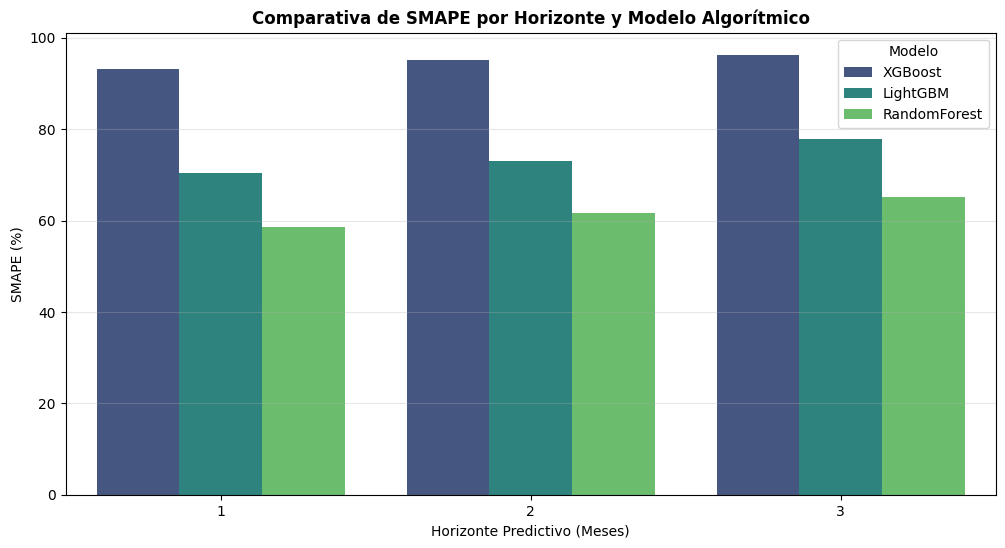

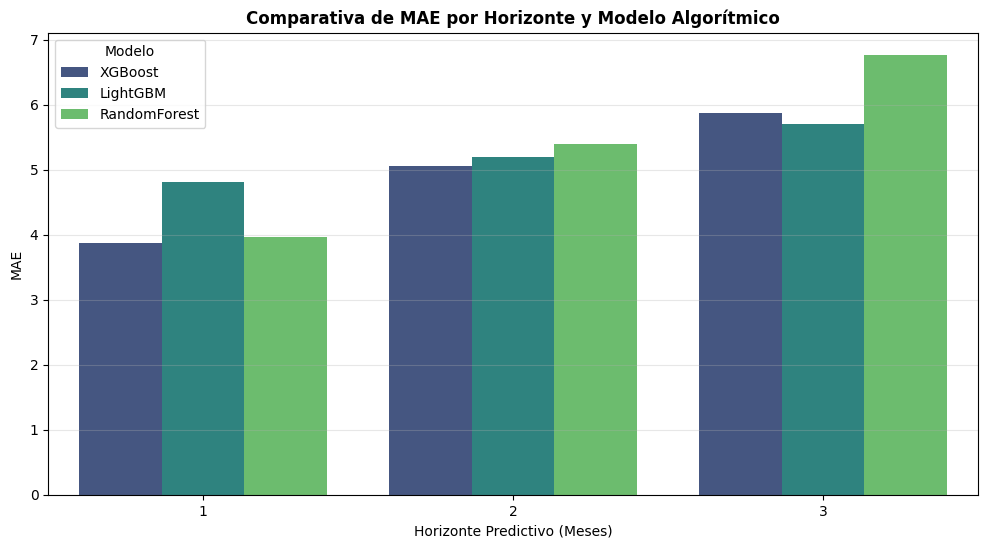

In [45]:
df_res = pd.DataFrame(resultados_globales)
display(df_res.sort_values(by=["Horizonte (Meses)", "RMSE"]))

# Gráfico de barras RMSE
plt.figure(figsize=(12, 6))
sns.barplot(data=df_res, x="Horizonte (Meses)", y="RMSE", hue="Modelo", palette="viridis")
plt.title("Comparativa de RMSE por Horizonte y Modelo Algorítmico", fontweight="bold")
plt.ylabel("RMSE")
plt.xlabel("Horizonte Predictivo (Meses)")
plt.grid(True, alpha=0.3, axis="y")
plt.show()

# Gráfico de barras SMAPE
plt.figure(figsize=(12, 6))
sns.barplot(data=df_res, x="Horizonte (Meses)", y="SMAPE", hue="Modelo", palette="viridis")
plt.title("Comparativa de SMAPE por Horizonte y Modelo Algorítmico", fontweight="bold")
plt.ylabel("SMAPE (%)")
plt.xlabel("Horizonte Predictivo (Meses)")
plt.grid(True, alpha=0.3, axis="y")
plt.show()

# Gráfico de barras MAE
plt.figure(figsize=(12, 6))
sns.barplot(data=df_res, x="Horizonte (Meses)", y="MAE", hue="Modelo", palette="viridis")
plt.title("Comparativa de MAE por Horizonte y Modelo Algorítmico", fontweight="bold")
plt.ylabel("MAE")
plt.xlabel("Horizonte Predictivo (Meses)")
plt.grid(True, alpha=0.3, axis="y")
plt.show()

Resultados 

Para h = 1 mes: RandomForest obtuvo RMSE = 12.2626 y SMAPE = 58.5887, mientras que XGBoost tiene la MAE más baja (3.8754) pero un SMAPE muy alto (93.1750). LightGBM presenta RMSE = 13.13998 y SMAPE = 70.3643. En términos prácticos, RandomForest es la opción preferida para h=1 porque minimiza el RMSE y el error relativo (SMAPE); XGBoost reduce ligeramente MAE pero su SMAPE sugiere que falla en predecir picos/relativos correctamente.

Para h = 2 meses: LightGBM muestra el mejor RMSE = 13.9102 (MAE = 5.2032, SMAPE = 73.0519). XGBoost tiene la MAE más baja (5.0636) pero RMSE y SMAPE elevados (15.7102 y 95.1032). RandomForest entrega SMAPE más bajo (61.6232) pero RMSE mayor (15.8072). Aquí hay un trade‑off: si priorizas RMSE/global accuracy, LightGBM es la mejor elección; si te preocupa el error relativo porcentual, RandomForest es mejor.

Para h = 3 meses: LightGBM lidera en MAE y RMSE (MAE = 5.6991, RMSE = 14.3601) y RandomForest obtiene el SMAPE más bajo (65.2452) aunque con RMSE mayor (17.2324). XGBoost de nuevo muestra SMAPE muy alto (96.2952). Para este horizonte LightGBM es la opción más consistente en errores absolutos/cuadráticos.

Conclusión general

LightGBM es el modelo más consistente en los horizontes medios/largos (h=2,3) y ofrece el mejor compromiso global en RMSE cuando se consideran los tres horizontes. RandomForest es más competitivo en h=1 y tiende a producir los menores SMAPE (mejor en error relativo), por lo que es preferible si la métrica crítica es SMAPE o la calibración relativa frente a picos. XGBoost entrega las MAE más bajas en algunos casos, pero sus SMAPE altos indican problemas con picos/calibración; usarlo requeriría ajustar/calibrar residuales antes de confiar en sus pronósticos.



